In [ ]:
import pandas as pd

url = 'https://docs.google.com/spreadsheets/d/1g1aQ61vijh6uHJuc8sijeBEMsoIQ2a5yLwUK04Wptlg/export?format=csv';

dataset = pd.read_csv(url);

# Link para o código Colab: https://colab.research.google.com/drive/1rDK17ejktxBOOU2So02ijvVW80rSHXYN?usp=sharing

In [ ]:
# 🔹 Mapeamento CORRETO (usando nomes completos das colunas)
COLUMN_MAP = {
    'Você ficou gripado no ano passado ?': 'ficou_gripado',
    'Você tomou vacina da gripe no ano passado?': 'vacina_gripe',
    '  Você frequentou no ano passado,  semanalmente ambientes com muitas pessoas? (salas cheias, ônibus, eventos, etc.)  ': 'frequentou_ambientes_cheios',
    '  Você viajou no ano passado mais de 100 km de distância?  ': 'viajou_100km',
    '  Você tem alergia nas vias aéreas (rinite, sinusite, etc.)?  ': 'alergia_vias_aereas',
    'Quantas horas você dormiu em média por noite no ano passado?': 'horas_sono',
    'Você praticou atividade física no ano passado?': 'atividade_fisica',
    'Você se alimentou de forma balanceada no ano passado?': 'alimentacao_balanceada',
    'Em média, quantas vezes você lavou as mãos por dia no ano passado?': 'lavou_maos_por_dia',
    'Na sua percepção, o seu nível de estresse no ano passado foi:': 'nivel_estresse',
}

# 🔹 Renomear dataset
ds_maped = dataset.rename(columns=COLUMN_MAP)

ds_maped["nivel_estresse"] = pd.cut(
    ds_maped["nivel_estresse"],
    bins=[0, 2, 4, 5],
    labels=["baixo", "medio", "alto"]
)

# 🔹 Definição de features
FEATURES = {
  "risk_exposure_score": ["frequentou_ambientes_cheios","viajou_100km",],
  "protection_score": ["vacina_gripe","lavou_maos_por_dia",],
  "health_score": ["atividade_fisica","alimentacao_balanceada","horas_sono",],
  "respiratory_vulnerability": ["alergia_vias_aereas","nivel_estresse",],
  "preventive_behavior_score": ["vacina_gripe","lavou_maos_por_dia","atividade_fisica","alimentacao_balanceada",],
  "lifestyle_balance": ["horas_sono","atividade_fisica","alimentacao_balanceada","nivel_estresse",],
  "immunity_behavior_index": ["horas_sono","alimentacao_balanceada","atividade_fisica","nivel_estresse",],
}

TARGET = 'ficou_gripado'

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter

# 🔹 Entropia
def entropy(y):
    counts = Counter(y)
    total = len(y)
    
    ent = 0
    for c in counts.values():
        p = c / total
        ent -= p * np.log2(p)
    
    return ent


# 🔹 Ganho de informação
def information_gain(df, feature, target):
    total_entropy = entropy(df[target])
    
    values = df[feature].unique()
    weighted_entropy = 0
    
    for v in values:
        subset = df[df[feature] == v]
        weight = len(subset) / len(df)
        weighted_entropy += weight * entropy(subset[target])
    
    return total_entropy - weighted_entropy


# 🔹 ID3 (recursivo)
def id3(df, features, target):
    
    # 🔹 Caso 1: todas classes iguais
    if len(df[target].unique()) == 1:
        return df[target].iloc[0]
    
    # 🔹 Caso 2: sem features
    if len(features) == 0:
        return df[target].mode()[0]
    
    # 🔹 Escolhe melhor feature
    gains = [information_gain(df, f, target) for f in features]
    best_feature = features[np.argmax(gains)]
    
    tree = {best_feature: {}}
    
    for value in df[best_feature].unique():
        subset = df[df[best_feature] == value]
        
        if subset.empty:
            tree[best_feature][value] = df[target].mode()[0]
        else:
            remaining_features = [f for f in features if f != best_feature]
            tree[best_feature][value] = id3(subset, remaining_features, target)
    
    return tree


# 🔹 Previsão
def predict(tree, sample):
    if not isinstance(tree, dict):
        return tree
    
    feature = list(tree.keys())[0]
    value = sample.get(feature)
    
    if value in tree[feature]:
        return predict(tree[feature][value], sample)
    else:
        return None

In [ ]:

# 🔹 Escolhendo um grupo de features
feature_cols = FEATURES["health_score"]

# 🔹 Criar árvore
tree = id3(ds_maped, feature_cols, TARGET)

print(tree)

sample = {
    "atividade_fisica": "sim",
    "alimentacao_balanceada": "não",
    "horas_sono": "baixo"
}

pred = predict(tree, sample)
print("Previsão:", pred)

In [ ]:
from sklearn.metrics import accuracy_score

# 🔹 Função de predição para várias linhas
def predict_df(tree, df):
    preds = []
    
    for _, row in df.iterrows():
        pred = predict(tree, row.to_dict())  # usa dict da linha
        preds.append(pred)
    
    return preds


# 🔹 Split correto (sem sobreposição)
train = ds_maped.iloc[:150]
test = ds_maped.iloc[150:]  # corrigido (antes estava sobrepondo)

# 🔹 Loop nas features
for feature_name, feature_cols in FEATURES.items():

    try:
        # 🔹 Treina árvore
        tree = id3(train, feature_cols, TARGET)

        # 🔹 Predição
        y_pred = predict_df(tree, test)
        y_true = test[TARGET]

        # 🔹 Remove possíveis None (casos não vistos na árvore)
        valid = [(yt, yp) for yt, yp in zip(y_true, y_pred) if yp is not None]
        
        if len(valid) == 0:
            print(f"Feature {feature_name}: sem previsões válidas\n")
            continue
        
        y_true_valid, y_pred_valid = zip(*valid)

        # 🔹 Avaliação
        print(f"Feature usada: {feature_name}")
        print("Acurácia real:", accuracy_score(y_true_valid, y_pred_valid))
        print("\n====================\n")

    except Exception as e:
        print(f"Feature {feature_name} deu erro: {e}\n")

# Com o Dataset da aula no dia 31/03/2026 deu um valor como arvore a resposta:



```
{'horas_sono': {'4 horas ou menos': 'Sim', 'entre 4 e 6 horas': {'atividade_fisica': {'Não': {'alimentacao_balanceada': {'Não, raramente': 'Sim', 'Às vezes': 'Sim', 'Sim, a maior parte do tempo': 'Não'}}, 'Sim': {'alimentacao_balanceada': {'Às vezes': 'Sim', 'Sim, a maior parte do tempo': 'Sim', 'Não, raramente': 'Sim'}}}}, 'mais de 6 horas': {'alimentacao_balanceada': {'Às vezes': {'atividade_fisica': {'Sim': 'Sim', 'Não': 'Não'}}, 'Sim, a maior parte do tempo': {'atividade_fisica': {'Sim': 'Sim', 'Não': 'Não'}}, 'Não, raramente': {'atividade_fisica': {'Sim': 'Não', 'Não': 'Não'}}}}}}
```

# Formando assim uma árvore de decisão proxima a está da imagem:

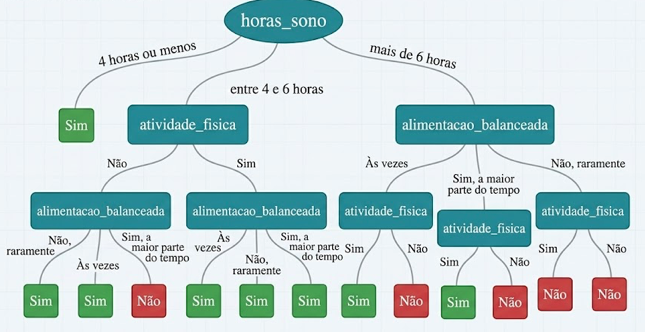